In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import import_ipynb
from ai_models.simca import SIMCAModel, SIMCAClassModel
from itertools import product
from pathlib import Path
%matplotlib inline

data/Replicate_011/Replicate_011_20251119: 10 FLUO files
data/Replicate_012/Replicate_012_20251119: 10 FLUO files
data/Replicate_021/Replicate_021_20251119: 10 FLUO files
data/Replicate_022/Replicate_022_20251119: 10 FLUO files

Ukupan broj XVOO_NONE FLUO merenja: 40
xvoo_none_raw shape: (40, 288)


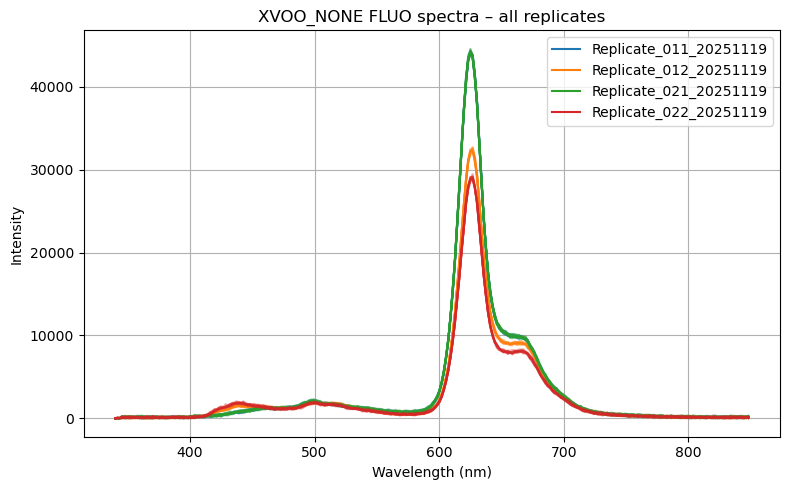

In [2]:
replicate_folders = [
    r"data/Replicate_011/Replicate_011_20251119",
    r"data/Replicate_012/Replicate_012_20251119",
    r"data/Replicate_021/Replicate_021_20251119",
    r"data/Replicate_022/Replicate_022_20251119",
    # r"data/Replicate_011/Replicate_011_20251230",
]

xvoo_none_raw = []
wavelengths = None
file_counter = 0

for base_folder in replicate_folders:
    xvoo_none_fluo_path = os.path.join(base_folder, "xvoo_none", "FLUO")

    if not os.path.exists(xvoo_none_fluo_path):
        print(f"Warning: {xvoo_none_fluo_path} does not exist, skipping...")
        continue

    files = sorted(glob.glob(os.path.join(xvoo_none_fluo_path, "*.csv")))
    print(f"{base_folder}: {len(files)} FLUO files")

    for fpath in files:
        df = pd.read_csv(fpath)

        if wavelengths is None:
            wavelengths = df["x"].values
        else:
            assert np.allclose(wavelengths, df["x"].values), \
                "Wavelengths do not match between replicates!"

        xvoo_none_raw.append(df["y"].values)
        file_counter += 1

xvoo_none_raw = np.array(xvoo_none_raw)

print(f"\nUkupan broj XVOO_NONE FLUO merenja: {file_counter}")
print("xvoo_none_raw shape:", xvoo_none_raw.shape)

plt.figure(figsize=(8, 5))

rep_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, base_folder in enumerate(replicate_folders):
    rep_name = os.path.basename(base_folder)
    
    start_idx = sum(len(glob.glob(os.path.join(f, "xvoo_none", "FLUO", "*.csv"))) 
                    for f in replicate_folders[:i])
    end_idx = start_idx + len(glob.glob(os.path.join(base_folder, "xvoo_none", "FLUO", "*.csv")))
    
    spectra = xvoo_none_raw[start_idx:end_idx]
    
    for spec in spectra:
        plt.plot(wavelengths, spec, color=rep_colors[i], alpha=0.4)
    
    plt.plot([], [], color=rep_colors[i], alpha=1, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("XVOO_NONE FLUO spectra – all replicates")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/UV/UV_xvoo_none_raw.png", dpi=300, bbox_inches="tight")
plt.show()

Replicate_011_20251119 WR shape: (288, 2)
Replicate_012_20251119 WR shape: (288, 2)
Replicate_021_20251119 WR shape: (288, 2)
Replicate_022_20251119 WR shape: (288, 2)


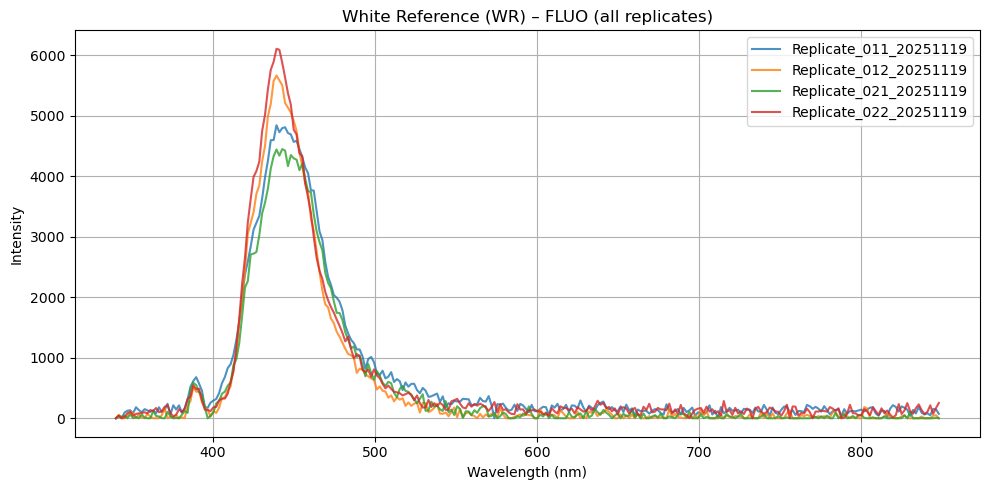

In [3]:
wr_fluo_dict = {}

for base_folder in replicate_folders:
    rep_name = os.path.basename(base_folder)  # ime replicata
    wr_path = os.path.join(base_folder, "wr", "FLUO_WR.csv")

    if not os.path.exists(wr_path):
        print(f"Warning: WR does not exist for {rep_name}")
        continue

    wr_df = pd.read_csv(wr_path)

    wl_wr = wr_df["x"].values
    I_wr = wr_df["y"].values

    wr_fluo_dict[rep_name] = I_wr

    print(f"{rep_name} WR shape:", wr_df.shape)

    if "wavelengths" in globals():
        assert np.allclose(wavelengths, wl_wr), f"{rep_name}: WR and spectra wavelengths do not match!"

plt.figure(figsize=(10, 5))

rep_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, base_folder in enumerate(replicate_folders):
    rep_name = os.path.basename(base_folder)
    I_wr = wr_fluo_dict[rep_name]
    wl_wr = wavelengths

    plt.plot(wl_wr, I_wr, color=rep_colors[i], alpha=0.8, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("White Reference (WR) – FLUO (all replicates)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/UV/UV_WR.png", dpi=300, bbox_inches="tight")
plt.show()

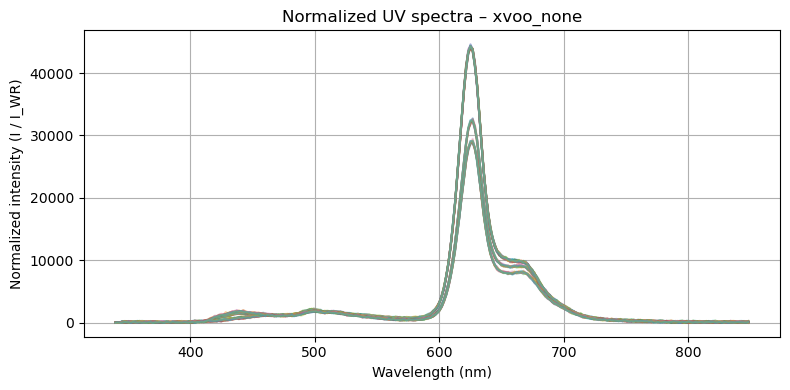

In [4]:
xvoo_none_norm = xvoo_none_raw / 1.0

plt.figure(figsize=(8, 4))

for i in range(len(xvoo_none_norm)):
    plt.plot(wavelengths, xvoo_none_norm[i], alpha=0.4)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity (I / I_WR)")
plt.title("Normalized UV spectra – xvoo_none")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
xvoo_none_norm.shape

(40, 288)

In [6]:
X = xvoo_none_norm
y = np.array(["XVOO_NONE"] * X.shape[0])

In [7]:
github_path = Path.home() / "Documents/Github"
ai_spectra = github_path / "aiSpectra" / "data"

datasets = [
    {
        "base_folder": ai_spectra / "Replicate_011/Replicate_011_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_oo50",
                     "xvoo_oo100", "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": ai_spectra / "Replicate_011/Replicate_011_20251205",
        "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
                     "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    },
    {
        "base_folder": ai_spectra / "Replicate_011/Replicate_011_20251230",
        "mixtures": ["xvoo_lso10", "xvoo_lso20", "xvoo_lso30", "xvoo_lso40",
                     "xvoo_lso60", "xvoo_lso70", "xvoo_lso80", "xvoo_lso90",
                     "xvoo_lso100", "xvoo_none", "xvoo_oo90"]
    },
    {
        "base_folder": ai_spectra / "Replicate_012/Replicate_012_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": ai_spectra / "Replicate_012/Replicate_012_20251205",
        "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
                     "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    },
    {
        "base_folder": ai_spectra / "Replicate_021/Replicate_021_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": ai_spectra / "Replicate_022/Replicate_022_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    }
]

In [8]:
X_list = []
y_list = []

for ds in datasets:
    base_folder = ds["base_folder"]
    mixtures = ds["mixtures"]

    wr_file = os.path.join(base_folder, "wr", "FLUO_WR.csv")
    wr = pd.read_csv(wr_file).iloc[:, 1].values

    print(f"\nLoading data from: {base_folder}")
    print(f"WR shape: {wr.shape}")

    for mix in mixtures:
        uv_folder = os.path.join(base_folder, mix, "FLUO")

        if not os.path.exists(uv_folder):
            print(f"Warning: folder does not exist {uv_folder}, skipping...")
            continue

        files = sorted([f for f in os.listdir(uv_folder) if f.endswith(".csv")])

        for f in files:
            df = pd.read_csv(os.path.join(uv_folder, f))
            spectrum = df.iloc[:, 1].values
            spectrum_norm = spectrum / 1.0

            X_list.append(spectrum_norm)
            y_list.append(mix)
    
X_all_norm = np.array(X_list)
y_all = np.array(y_list)

print("Shape X_all_norm:", X_all_norm.shape)
print("Shape y_all:", y_all.shape)

print("Unique classes:", np.unique(y_all))


Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_011/Replicate_011_20251119
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_011/Replicate_011_20251205
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_011/Replicate_011_20251230
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_012/Replicate_012_20251119
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_012/Replicate_012_20251205
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_021/Replicate_021_20251119
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/Replicate_022/Replicate_022_20251119
WR shape: (288,)
Shape X_all_norm: (1010, 288)
Shape y_all: (1010,)
Unique classes: ['xvoo_lso10' 'xvoo_lso100' 'xvoo_lso20' 'xvoo_lso30' 'xvoo_lso40'
 'xvoo_lso50' 'xvoo_lso60'

In [9]:
modes = ['rigorous', 'compliant']
rules = ['sim', 'alt', 'ci', 'dd']
od_methods = ['percentile', 'jackson', 'box']
sd_methods = ['f', 'chi2', 'percentile']

best_accuracy = 0
best_params = None
best_model = None

for mode, rule, od_method, sd_method in product(modes, rules, od_methods, sd_methods):
    try:
        simca = SIMCAModel(alpha=0.05, default_n_components=None)
        comp_grid = list(range(1, min(10, X.shape[1])+1))
        best_components = simca.tune_num_components(
            X, y,
            comp_grid=comp_grid,
            cv=5,
            mode=mode,
            rule=rule,
            od_method=od_method,
            sd_method=sd_method
        )
        optimal_n = list(best_components.values())[0]
        simca.fit(X, y, n_components=optimal_n)
        simca.set_thresholds_all(od_method=od_method, sd_method=sd_method)
        results = simca.predict(X_all_norm, rule=rule)
        res = results['XVOO_NONE']
        inside = res['inside']

        y_true = np.array([1 if label == 'XVOO_NONE' else 0 for label in y_all])
        y_pred = np.array([1 if accepted else 0 for accepted in inside])
        accuracy = np.mean(y_true == y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params = {
                'mode': mode,
                'rule': rule,
                'od_method': od_method,
                'sd_method': sd_method,
                'n_components': optimal_n,
                'accuracy': accuracy
            }
            best_model = simca
    except Exception as e:
        print(f"Combination failed: mode={mode}, rule={rule}, od_method={od_method}, sd_method={sd_method} -> {e}")
        continue

print("Best parameters found:")
print(best_params)
print(f"Best accuracy: {best_accuracy*100:.2f}%")

Best parameters found:
{'mode': 'rigorous', 'rule': 'sim', 'od_method': 'jackson', 'sd_method': 'f', 'n_components': 1, 'accuracy': np.float64(1.0)}
Best accuracy: 100.00%


In [10]:
if best_model is not None:
    results_mix = best_model.predict(X_all_norm, rule=best_params['rule'])
    res_mix = results_mix['XVOO_NONE']
    
    ODcrit = best_model.class_models['XVOO_NONE'].thresholds['ODcrit']
    SDcrit = best_model.class_models['XVOO_NONE'].thresholds['SDcrit']

    print("OD threshold:", ODcrit)
    print("SD threshold:", SDcrit)
    
    inside = res_mix['inside']

OD threshold: 1072008.5581867464
SD threshold: 4.1935605219491325


In [11]:
%matplotlib qt

In [12]:
SD = res_mix['SD']
OD = res_mix['OD']

classes = np.unique(y_all)
num_classes = len(classes)

cmap = plt.get_cmap("tab20")
class_colors = {cls: cmap(i / num_classes) for i, cls in enumerate(classes)}

plt.figure(figsize=(8,5))

for cls in classes:
    idx = y_all == cls
    plt.scatter(
        SD[idx],
        OD[idx],
        color=class_colors[cls],
        edgecolor='k',
        label=cls,
        s=60
    )

plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

plt.xlabel("Score Distance (SD)", fontsize=18)
plt.ylabel("Orthogonal Distance (OD)", fontsize=18)
plt.title("SIMCA – All UV data by class", fontsize=22)
plt.legend(
    loc='upper left',
    ncol=2,
    fontsize=12,
    frameon=True
)
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
y_true = np.array([label == "xvoo_none" for label in y_all])

y_pred = res_mix['inside']

TP = np.sum((y_true == True) & (y_pred == True))
FN = np.sum((y_true == True) & (y_pred == False))
FP = np.sum((y_true == False) & (y_pred == True))
TN = np.sum((y_true == False) & (y_pred == False))

conf_matrix = pd.DataFrame(
    [[TP, FN],
     [FP, TN]],
    index=["True XVOO", "True MIX"],
    columns=["Predicted IN", "Predicted OUT"]
)

conf_matrix

,Predicted IN,Predicted OUT
True XVOO,0,50
True MIX,0,960


In [14]:
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Sensitivity (Recall for XVOO): {sensitivity*100:.2f}%")
print(f"Specificity (Rejection of MIX): {specificity*100:.2f}%")
print(f"Accuracy: {accuracy*100:.2f}%")

Sensitivity (Recall for XVOO): 0.00%
Specificity (Rejection of MIX): 100.00%
Accuracy: 95.05%


In [15]:
results_table = pd.DataFrame({
    "Sample index": np.arange(len(y_all)),
    "True label": y_all,
    "SIMCA accepted": y_pred,
    "Decision": np.where(y_pred, "Accepted", "Rejected"),
    "SD": res_mix['SD'],
    "OD": res_mix['OD']
})

results_table.head(10)

,Sample index,True label,SIMCA accepted,Decision,SD,OD
0,0,xvoo_lso50,False,Rejected,0.019356,3.387205e+08
1,1,xvoo_lso50,False,Rejected,0.017693,3.367685e+08
2,2,xvoo_lso50,False,Rejected,0.017163,3.288162e+08
3,3,xvoo_lso50,False,Rejected,0.018078,3.318325e+08
4,4,xvoo_lso50,False,Rejected,0.016093,3.393275e+08
5,5,xvoo_lso50,False,Rejected,0.017276,3.325851e+08
6,6,xvoo_lso50,False,Rejected,0.017026,3.379357e+08
7,7,xvoo_lso50,False,Rejected,0.021844,3.348516e+08
8,8,xvoo_lso50,False,Rejected,0.018501,3.379721e+08
9,9,xvoo_lso50,False,Rejected,0.015870,3.496272e+08
